# EDA: Quora Question Pairs

Exploratory analysis of the training data -- structure, class balance, missing values, and feature-vs-label distributions -- used to decide which hand-crafted features go into `src/features.py`.

## Import

In [95]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [96]:
%pip install optuna
%pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [97]:
import sys
sys.path.append('..')

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances
import wordcloud
from wordcloud import WordCloud, STOPWORDS
from src.features import add_all_features, preprocess_text
from src.utils import plot_class_split_hist, find_mismatched_cases
from src.evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix
from src.evaluation import train_and_evaluate, quick_log_loss
from sklearn.metrics import f1_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import optuna

pd.set_option('display.max_colwidth', None)

## Data loading

In [99]:
raw_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_question_pairs_train_.csv', index_col = 0)

In [100]:
raw_df

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0
196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0
113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0
266232,101283,163744,Which is the best place to reside in India and Why?,Which ia the best place to visit in India?,0
122738,17811,27517,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Google or Bing?,Why don't many people posting questions on Quora check Google first?,1
...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have about Myanmar and to what extent are they true?,What are the major stereotypes people have about Jordan and to what extent are they true?,0
90934,152504,152505,What are some of the best and most creative print advertisements you have ever seen?,Which is one of the worst and most insensible advertisements you have ever seen on TV?,0
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0


## EDA

In [101]:
raw_df.describe()

,qid1,qid2,is_duplicate
count,323432.000000,323432.000000,323432.000000
mean,217326.769030,221048.081142,0.369197
std,157709.127417,159882.933077,0.482588
min,1.000000,2.000000,0.000000
25%,74614.750000,74859.500000,0.000000
50%,192394.500000,197271.500000,0.000000
75%,346599.250000,354727.000000,1.000000
max,537932.000000,537933.000000,1.000000


In [102]:
raw_df.info()

<class 'pandas.DataFrame'>
Index: 323432 entries, 332278 to 402019
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   qid1          323432 non-null  int64
 1   qid2          323432 non-null  int64
 2   question1     323431 non-null  str  
 3   question2     323430 non-null  str  
 4   is_duplicate  323432 non-null  int64
dtypes: int64(3), str(2)
memory usage: 51.8 MB


In [103]:
#searching for rows with null values
print(raw_df.isnull().sum())

qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [104]:
# indices of rows with null values
null_idx = raw_df.isnull().any(axis=1)
print(raw_df[null_idx])

          qid1    qid2                         question1  \
id                                                         
363362  493340  493341                               NaN   
201841  303951  174364  How can I create an Android app?   
105780  174363  174364    How can I develop android app?   

                                                                                                                          question2  \
id                                                                                                                                    
363362  My Chinese name is Haichao Yu. What English name is most suitable for me considering the pronounciation of my Chinese name?   
201841                                                                                                                          NaN   
105780                                                                                                                          NaN   

        is_duplicate  


In [105]:
#deleting the row with null values ​​and overwrite the dataframe
raw_df = raw_df.dropna(subset=['question1', 'question2']).copy()

### Conclusion:
Out of 323432 rows, only 3 had missing values. Removing them would not affect the solution of the problem, so I removed them

In [106]:
#Checking class imbalance
raw_df.is_duplicate.value_counts(normalize=True)

is_duplicate
0    0.6308
1    0.3692
Name: proportion, dtype: float64

([<matplotlib.axis.XTick at 0x352d52e90>,
 [Text(0, 0, 'Not duplicate'), Text(1, 0, 'Duplicate')])

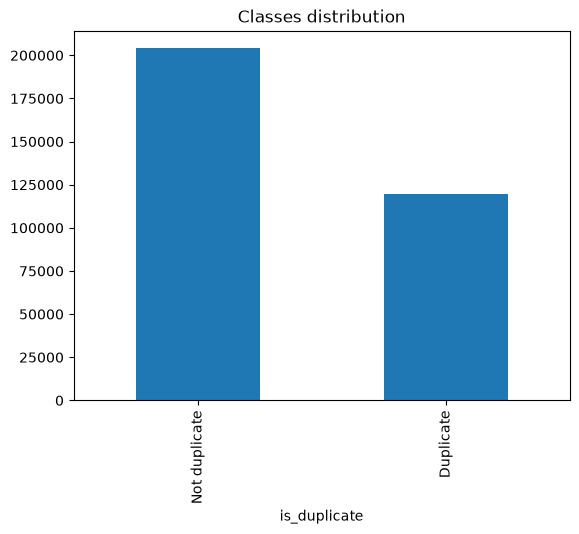

In [107]:
raw_df.is_duplicate.value_counts().plot(kind='bar')
plt.title('Classes distribution')
plt.xticks([0,1], ['Not duplicate', 'Duplicate'])

## Feature generation & more EDA

In [108]:

add_all_features(raw_df, q1_col="question1", q2_col="question2")


,qid1,qid2,question1,question2,is_duplicate,question1_len,question2_len,len_dif,common_words,jaccard_similarity,word_match_share,bigrams_common,bigram_jaccard_similarity,bigram_word_match_share,cosine_similarity
id,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0,47,81,-34,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0,62,55,7,3.0,0.600000,0.375000,1.0,0.200000,0.166667,0.827243
113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0,32,78,-46,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.149953
266232,101283,163744,Which is the best place to reside in India and Why?,Which ia the best place to visit in India?,0,51,42,9,2.0,0.250000,0.200000,1.0,0.142857,0.125000,0.345153
122738,17811,27517,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Google or Bing?,Why don't many people posting questions on Quora check Google first?,1,159,68,91,4.0,0.235294,0.190476,1.0,0.055556,0.052632,0.233961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have about Myanmar and to what extent are they true?,What are the major stereotypes people have about Jordan and to what extent are they true?,0,90,89,1,5.0,0.714286,0.416667,3.0,0.428571,0.300000,0.736964
90934,152504,152505,What are some of the best and most creative print advertisements you have ever seen?,Which is one of the worst and most insensible advertisements you have ever seen on TV?,0,84,86,-2,1.0,0.111111,0.100000,0.0,0.000000,0.000000,0.415535
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0,45,49,-4,1.0,0.142857,0.125000,0.0,0.000000,0.000000,0.569104


In [109]:
raw_df.to_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_with_features.csv', index=True)

In [110]:
print(raw_df['question1_len'].describe())

count    323429.000000
mean         59.531761
std          29.921286
min           1.000000
25%          39.000000
50%          52.000000
75%          72.000000
max         623.000000
Name: question1_len, dtype: float64


In [111]:
print(raw_df['question2_len'].describe())

count    323429.000000
mean         60.123242
std          33.889595
min           1.000000
25%          39.000000
50%          51.000000
75%          72.000000
max        1169.000000
Name: question2_len, dtype: float64


In [112]:
#deviding full test set on 2 subsets: duplicates and not_duplicates

duplicates = raw_df[raw_df['is_duplicate'] == 1]
not_duplicates = raw_df[raw_df['is_duplicate'] == 0]

### Analysis of statistical moments of duplicates and not_duplicates

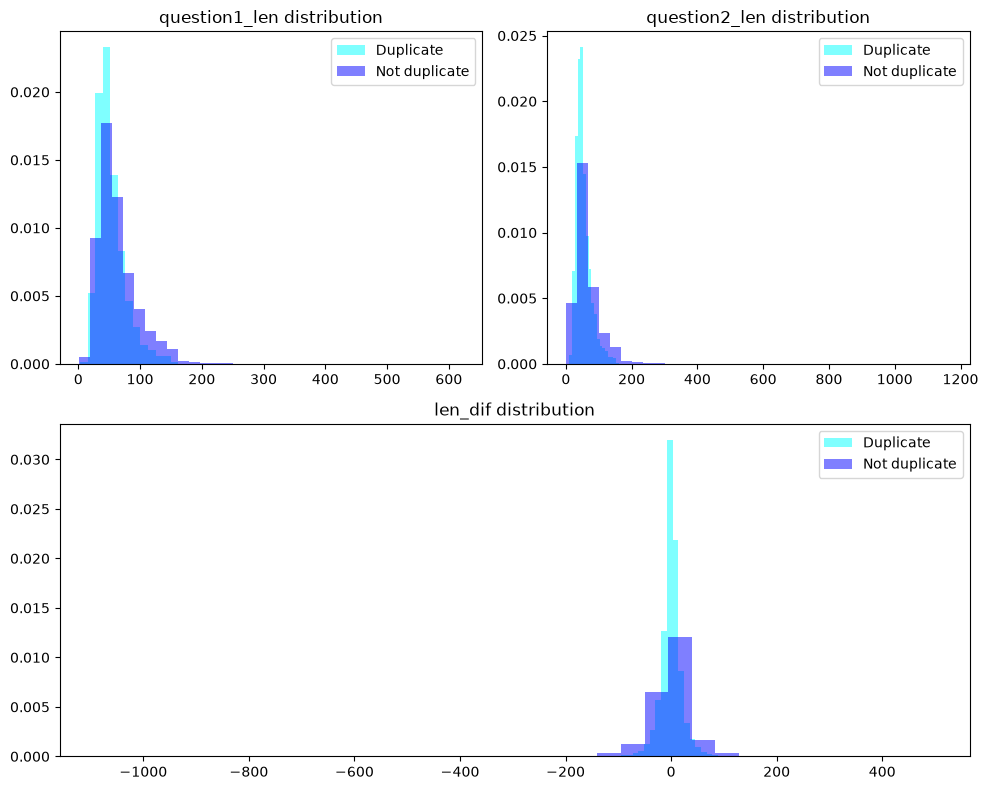

In [113]:
plt.figure(figsize=(10,8))

plt.subplot(2, 2, 1)
plot_class_split_hist(duplicates, not_duplicates, 'question1_len')

plt.subplot(2, 2, 2)
plot_class_split_hist(duplicates, not_duplicates, 'question2_len')

plt.subplot(2, 1, 2)
plot_class_split_hist(duplicates, not_duplicates, 'len_dif')

plt.tight_layout()
plt.show()

In [114]:
print(f'Q1 length variance in duplicates: {duplicates['question1_len'].var()}')
print(f'Q1 length variance in not_duplicates: {not_duplicates['question1_len'].var()}')

Q1 length variance in duplicates: 544.3865850328837
Q1 length variance in not_duplicates: 1058.9736062179281


In [115]:
print(f'Q2 length variance in duplicates: {duplicates['question2_len'].var()}')
print(f'Q2 length variance in not_duplicates: {not_duplicates['question2_len'].var()}')

Q2 length variance in duplicates: 540.8729156994409
Q2 length variance in not_duplicates: 1455.9419173519248


In [116]:
print(f'Q1 length kurtosis in duplicates: {duplicates['question1_len'].kurtosis()}')
print(f'Q1 length kurtosis in not_duplicates: {not_duplicates['question1_len'].kurtosis()}')

Q1 length kurtosis in duplicates: 4.171344166726708
Q1 length kurtosis in not_duplicates: 4.6548898572360144


In [117]:
print(f'Q2 length kurtosis in duplicates: {duplicates['question2_len'].kurtosis()}')
print(f'Q2 length kurtosis in not_duplicates: {not_duplicates['question2_len'].kurtosis()}')

Q2 length kurtosis in duplicates: 3.702451437092854
Q2 length kurtosis in not_duplicates: 50.62466344406163


In [118]:
print(f'Length difference Q1-Q2 variance in duplicates: {duplicates['len_dif'].var()}')
print(f'Length difference Q1-Q2 variance in not_duplicates: {not_duplicates['len_dif'].var()}')

Length difference Q1-Q2 variance in duplicates: 380.5788105790839
Length difference Q1-Q2 variance in not_duplicates: 1460.0427132430757


In [119]:
print(f'Length difference Q1-Q2 kurtosis in duplicates {duplicates['len_dif'].kurtosis()}')
print(f'Length difference Q1-Q2 kurtosis in not_duplicates: {not_duplicates['len_dif'].kurtosis()}')

Length difference Q1-Q2 kurtosis in duplicates 4.798909321034921
Length difference Q1-Q2 kurtosis in not_duplicates: 39.13918674415612


### Unique words analysis

In [120]:
Q1_Q2_series = pd.concat([raw_df['question1'], raw_df['question2']], ignore_index=True)

In [121]:
Q1_Q2_series

0                                                                                                                         The Iliad and the Odyssey in the Greek culture?
1                                                                                                          What is practical management and what is strategic management?
2                                                                                                                                        How useful is MakeUseOf Answers?
3                                                                                                                     Which is the best place to reside in India and Why?
4         Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Google or Bing?
                                                                                       ...                                                            

In [122]:
#conversion to vectors
vectorizer = CountVectorizer(stop_words='english')

vect_questions = vectorizer.fit(Q1_Q2_series)

vect_q1 = vectorizer.transform(raw_df.question1)
vect_q2 = vectorizer.transform(raw_df.question2)

In [123]:
print(f"Total number of unique words: {len(vectorizer.vocabulary_)}")

Total number of unique words: 77733


In [124]:
total_matrix = vect_q1 + vect_q2
word_freq = total_matrix.sum(axis=0).A1
most_freq_words = pd.Series(word_freq, index=vectorizer.get_feature_names_out())


Text(0.5, 1.0, 'The least used words')

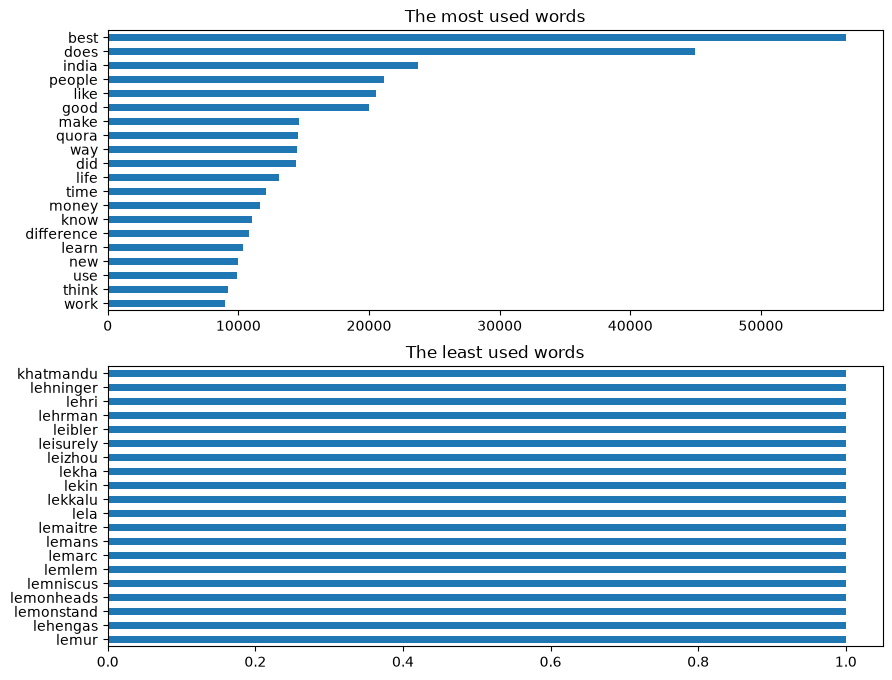

In [125]:
plt.figure(figsize=(10,8))
plt.subplot(2, 1, 1)
most_freq_words.sort_values(ascending=False).head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('The most used words')


plt.subplot(2, 1, 2)
most_freq_words.sort_values(ascending=True).head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('The least used words')

Observation:
- classes are unbalanced
- question length distributions are right-skewed
- duplicate class length distribution has lower variance and higher kurtosis
- entire question set has 77733 (without stop_words='english') unique words
- least frequently used words are sets of numbers and symbols (non-Latin)*
*after adding text preprocessing, the most rare words - are real non-commonly used words

## Q1 vs Q2 comparison

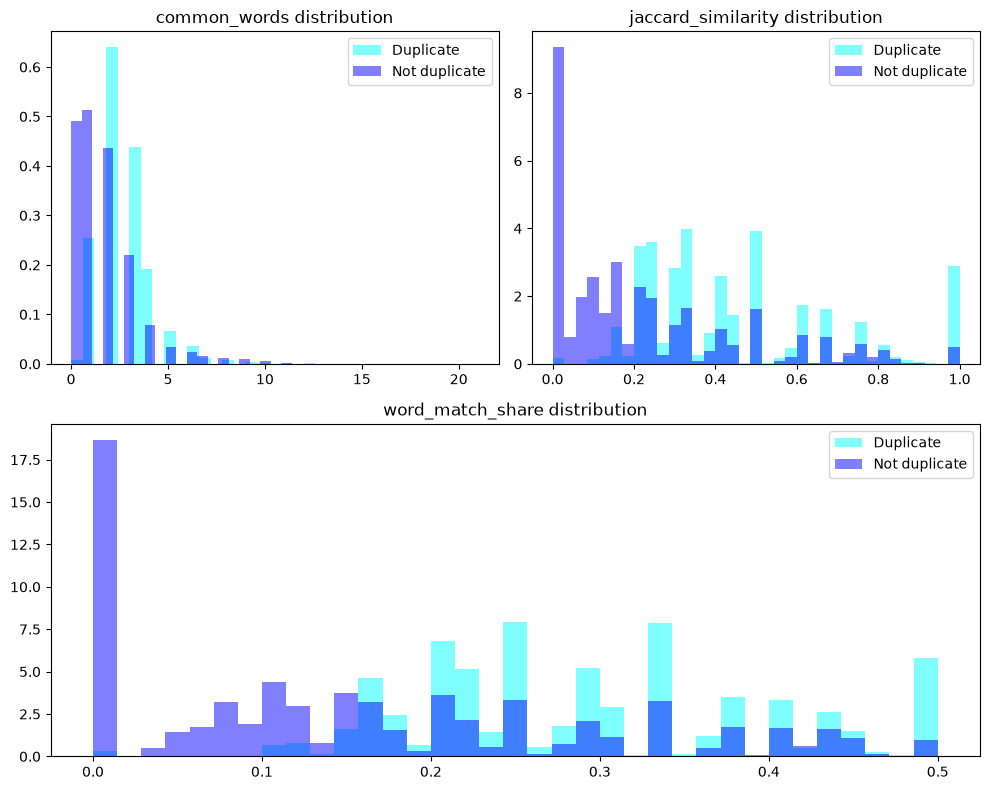

In [126]:
#Defining the number of common words and part of common words relatively to all words in Q1 and Q2
plt.figure(figsize=(10,8))

plt.subplot(2, 2, 1)
plot_class_split_hist(duplicates, not_duplicates, 'common_words')

plt.subplot(2, 2, 2)
plot_class_split_hist(duplicates, not_duplicates, 'jaccard_similarity')

plt.subplot(2, 1, 2)
plot_class_split_hist(duplicates, not_duplicates, 'word_match_share')

plt.tight_layout()
plt.show()

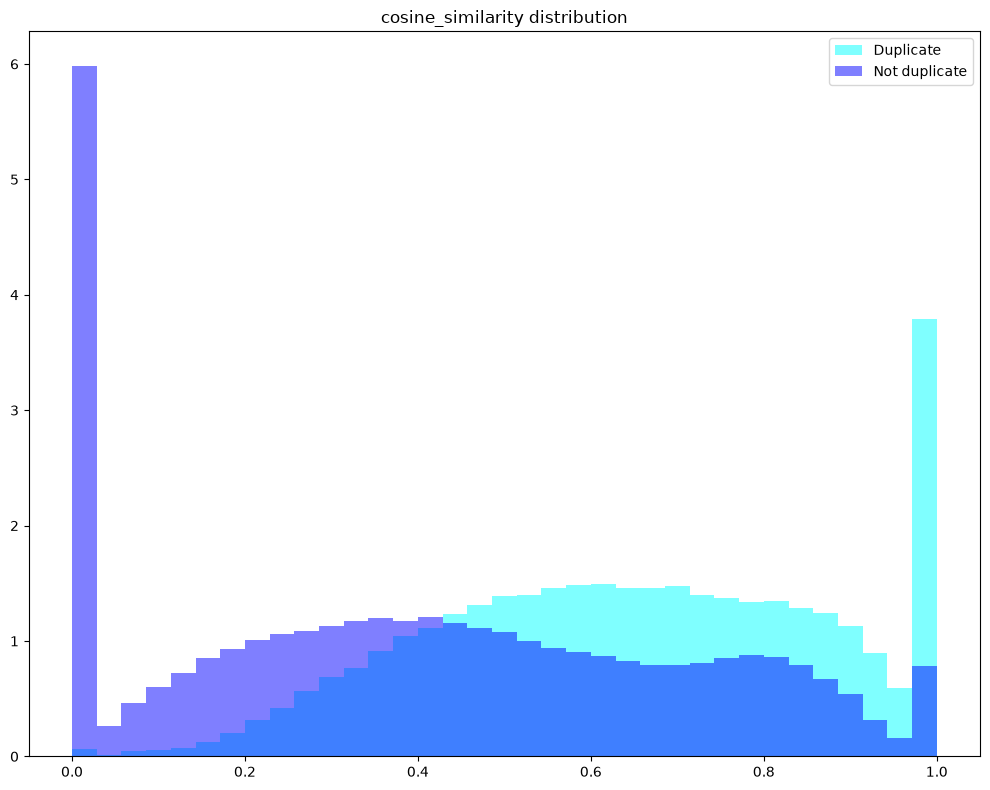

In [127]:
#cosine similarity

plt.figure(figsize=(10,8))

plot_class_split_hist(duplicates, not_duplicates, 'cosine_similarity')

plt.tight_layout()
plt.show()

Observation:
jaccard_similarity, word_match_share have different distributions for duplicate/not duplicate classes, so they can be informative features for the model. For the common_words distribution, the difference is not so noticeable, but I will leave this feature as well.
cosine_similarity - has the largest difference in distributions for duplicates and non-duplicates.

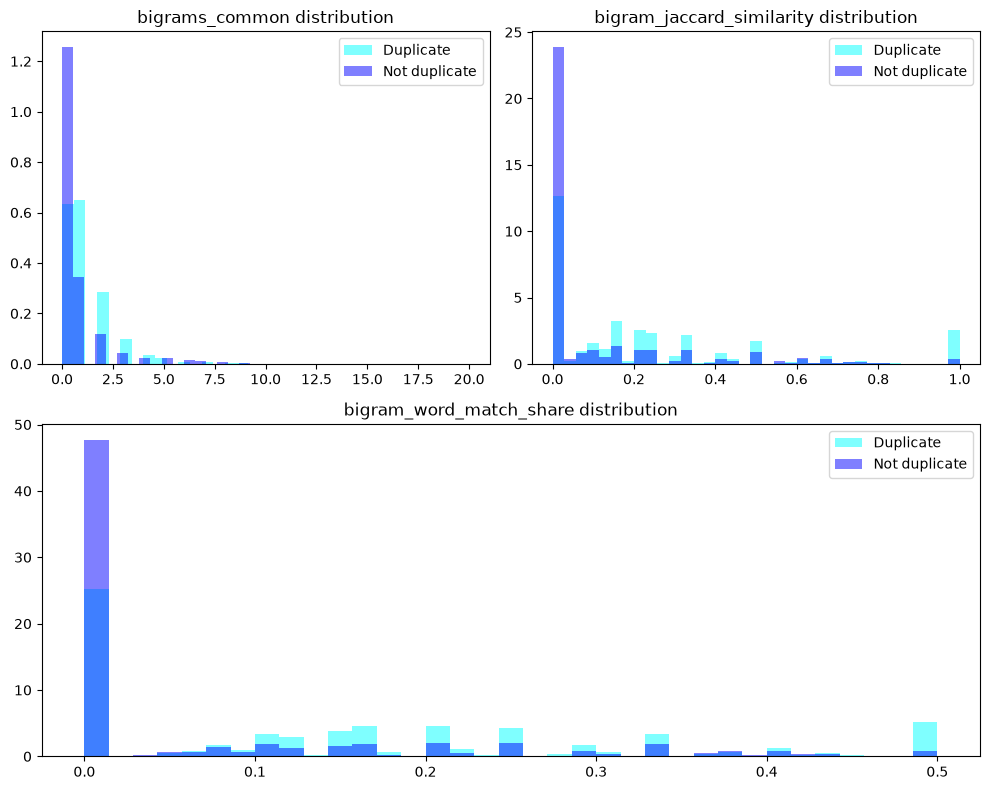

In [128]:
#bigram conparison

plt.figure(figsize=(10,8))

plt.subplot(2, 2, 1)
plot_class_split_hist(duplicates, not_duplicates, 'bigrams_common')

plt.subplot(2, 2, 2)
plot_class_split_hist(duplicates, not_duplicates, 'bigram_jaccard_similarity')

plt.subplot(2, 1, 2)
plot_class_split_hist(duplicates, not_duplicates, 'bigram_word_match_share')

plt.tight_layout()
plt.show()

Observation: bigrams turned out to be a not very informative feature because they are not sensitive to paraphrasing and are sensitive to word order, so in most cases questions do not have common bigrams.

In [129]:
#building a wordcloud for duplicates and non-duplicates

cloud_duplicates = ''.join(duplicates['question1'].tolist() + duplicates['question2'].tolist())
cloud_not_duplicates = ''.join(not_duplicates['question1'].tolist() + not_duplicates['question2'].tolist())

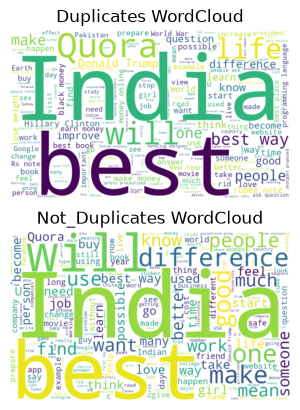

In [130]:
wc_duplicates = WordCloud(
    width =1000,
    height = 600,
    background_color = 'white',
    stopwords = STOPWORDS
    ).generate(cloud_duplicates)

wc_not_duplicates = WordCloud(
    width = 1000,
    height = 600,
    background_color = 'white',
    stopwords = STOPWORDS
    ).generate(cloud_not_duplicates)

plt.subplot(2,1,1)
plt.imshow(wc_duplicates, interpolation='bilinear')
plt.title('Duplicates WordCloud')
plt.axis('off')

print('\n')

plt.subplot(2,1,2)
plt.imshow(wc_not_duplicates, interpolation='bilinear')
plt.title('Not_Duplicates WordCloud')
plt.axis('off')

plt.show()

Observation:
WordCloud showed that both categories have a similar set of words. That is, the general search topic coincides for all questions, the difference should be sought in the pairs of questions.

## Search for cases where similarity does not match the label

In [131]:
false_similar_jac = find_mismatched_cases(raw_df, 'jaccard_similarity', 0.5, direction='above', target_label=0)

false_similar_cos = find_mismatched_cases(raw_df, 'cosine_similarity', 0.6, direction='above', target_label=0)

false_unsimilar_jac = find_mismatched_cases(raw_df, 'jaccard_similarity', 0.1, direction='below', target_label=1)

false_unsimilar_cos = find_mismatched_cases(raw_df, 'cosine_similarity', 0.2, direction='below', target_label=1)



In [132]:
false_similar_jac[['question1', 'question2', 'jaccard_similarity']]

,question1,question2,jaccard_similarity
id,,,
196656,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0.600000
239687,When did you join Quora?,Why did I join Quora?,1.000000
366190,What are the disadvantages of hiring foreign workers?,What are the advantages of hiring foreign workers?,0.600000
119588,What universities does Spectrum Brands recruit new grads from? What majors are they looking for?,What universities does Boulder Brands recruit new grads from? What majors are they looking for?,0.833333
331082,What are some home remedies for braces pain?,What are the home remedies for heels pain?,0.600000
...,...,...,...
48765,What are the best brands for Punching bags in UK?,What are the best brands for Punching bags in India?,0.666667
383049,How is life going?,Where is my life going?,1.000000
9428,How can I find a job in China?,How can one find a job outside of China?,0.666667


In [133]:
false_similar_cos[['question1', 'question2', 'cosine_similarity']]

,question1,question2,cosine_similarity
id,,,
196656,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0.827243
241523,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they different?,0.861547
239687,When did you join Quora?,Why did I join Quora?,1.000000
298798,How do I download free movies from torrent?,How do I download from torrent?,0.778948
86769,What is the skateboarding scene in India like?,What are the best skateboarding movies?,0.618402
...,...,...,...
383049,How is life going?,Where is my life going?,1.000000
9428,How can I find a job in China?,How can one find a job outside of China?,0.726931
212748,Do employees at Safe Bulkers have a good work-life balance? Does this differ across positions and departments?,Do employees at Scorpio Bulkers have a good work-life balance? Does this differ across positions and departments?,0.882781


In [134]:
false_unsimilar_jac[['question1', 'question2', 'jaccard_similarity']].head(20)

,question1,question2,jaccard_similarity
id,,,
307736,How can I get a PhD quickly?,How can I get a PhD?,0.000000
255552,"After our 1st date that lasted only 90 mins for dinner, he tried to kiss me and texted saying he had a lot of fun. Is he interested or being nice?",Would a guy try and kiss you and text right after the first date that he had fun if he was just being polite and not interested?,0.090909
163739,How do you get top writer?,"How do I become the Top Writer on Quora, get more upvotes and better stats?",0.000000
381292,How much time do you need to spend on Quora to become a top writer?,How do you become the top writer on Quora?,0.000000
31249,Would a guy try and kiss you and text right after the first date that he had fun if he was just being polite and not interested?,"If a man texted five minutes after the first date to say he had fun, why won't he text me the next day? How can he be trying to play it cool now?",0.095238
83857,How do I become mentally stronger?,How can I become strong mentally?,0.000000
131981,How can I get my hair to be healthy?,What should I do to get healthy hair?,0.000000
200431,How do i get myself a girlfriend?,How do I get a girl's attention?,0.000000
249584,"My cat died, how do I get over this?",How can I get over the death of my cat?,0.000000


In [135]:
false_unsimilar_cos[['question1', 'question2', 'cosine_similarity']].head(20)

,question1,question2,cosine_similarity
id,,,
64894,Is the human life more important than the life of other creatures?,Do human lives have any more value than other animals lives?,0.125274
342038,What are the best online sites to learn computer programming?,What is the best website to learn coding independently?,0.173192
164040,How do I lose weight ayurvedically?,How can I loose weight for wedding?,0.180115
397565,What are the differences between BI tools and analytics tools?,What is the difference between Business Analytics and Business Intelligence?,0.188860
201003,How does crowdfunding work?,How does a crowd-funding portal/website work?,0.180094
8386,What is a good first car for a teen guy?,What's the ideal first car for teens?,0.195494
236667,What are the effects of demonetization in India?,Is demonetisation good for India?,0.156610
112786,How can I speaking fluently speaking English?,How can I continue to improve my English?,0.146121
334807,Is their any way you can PM someone on Quora?,How do I personal message someone on Quora?,0.190412


Observations
- cases where there is no duplicate tag, but there is a high jaccard_similarity or cosine_similarity - this is a sentence with 1 or a pair of words that are different, and this changes the context or meaning of the sentence

- cases where there is a duplicate tag, but a low jaccard_similarity or cosine_similarity, the sentences use synonymous expressions that mean the same thing, or different parts of speech with a common root, or metaphors

In [137]:
#test of preprocessing function
preprocess_text("What questions are running late?")

'questions running late?'